# Exploratory data analysis

## 1. Notebook setup

### 1.1. Imports

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

### 1.2. Data loading

In [2]:
df = pd.read_csv('../data/train.csv')

## 2. Data inspection

### 2.1. Shape, format & summary statistics

In [3]:
df.head().T

,0,1,2,3,4
id,0,1,2,3,4
health_condition,unhealthy,at-risk,unhealthy,unhealthy,at-risk
sleep_duration,5.22,5.53,5.29,4.7,7.23
heart_rate,70.6,71.3,75.4,77.2,73.4
bmi,25.66,25.84,24.54,23.13,28.44
calorie_expenditure,2174.0,1966.0,2688.0,2630.0,2560.0
step_count,1326.0,9891.0,14216.0,7174.0,6584.0
exercise_duration,19.8,49.9,38.1,59.9,46.0
water_intake,1.86,1.26,1.6,2.02,2.25
diet_type,veg,non-veg,veg,veg,veg


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,690088.0,345043.500000,199211.390620,0.0,172521.75,345043.50,517565.25,690087.00
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


The label is `health_condition`, comes in as object dtype, appears to contain string/categorical data. The 14 other columns are features. The `id` column can be dropped, leaving us 13 information containing features to work with.

In [6]:
features = [
    'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
    'step_count', 'exercise_duration', 'water_intake', 'diet_type',
    'stress_level', 'sleep_quality', 'physical_activity_level',
    'smoking_alcohol', 'gender'
]

label = 'health_condition'

### 2.2.Missing values

In [7]:
df.isna().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

All features have missing values, ranging from ~1.0% to ~1.2%.

In [8]:
# Get null counts by label
null_counts = df.drop('id', axis=1).isnull().groupby(df['health_condition']).sum()

# Drop the label null counts (which is zero
null_counts.drop('health_condition', axis=1, inplace=True)

display(null_counts.T)

health_condition,at-risk,fit,unhealthy
sleep_duration,65308,4356,6335
heart_rate,6821,433,579
bmi,12352,1139,407
calorie_expenditure,45350,3065,4438
step_count,11997,793,1126
exercise_duration,5872,417,612
water_intake,37177,2524,3776
diet_type,5987,351,563
stress_level,71130,4759,6922
sleep_quality,50143,3394,4794


In [9]:
results = {}

for col in features:

    # 1. Create a binary indicator for missingness (True if null, False if not)
    is_null = df[col].isnull()
    
    # 2. Build the 2 x 3 cross-tabulation table
    contingency_table = pd.crosstab(is_null, df[label])
    
    # 3. Run the Chi-squared test
    # stat: Chi-sq statistic, p: p-value, dof: degrees of freedom, expected: expected frequencies
    stat, p, dof, expected = chi2_contingency(contingency_table)
    
    # 4. Check assumption: are any expected cell counts less than 5?
    low_expected_counts = (expected < 5).any()
    
    results[col] = {
        'p_value': p,
        'chi2_stat': stat,
        'violates_assumption': low_expected_counts
    }

# Convert results to a readable DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

                          p_value   chi2_stat violates_assumption
sleep_duration           0.851123    0.322396               False
heart_rate               0.003861   11.113873               False
bmi                           0.0  660.986375               False
calorie_expenditure      0.907254    0.194666               False
step_count               0.453612    1.581028               False
exercise_duration        0.172269    3.517399               False
water_intake             0.038828    6.497219               False
diet_type                0.036695    6.610203               False
stress_level             0.958954    0.083824               False
sleep_quality            0.371979    1.977834               False
physical_activity_level  0.900317    0.210017               False
smoking_alcohol          0.495606     1.40395               False
gender                   0.217861    3.047798               False


The distribution of null values in several features appears to have a significant association with the label.

In [10]:
sig_features = results_df[results_df['p_value'] < 0.05].index
display(sig_features)

Index(['heart_rate', 'bmi', 'water_intake', 'diet_type'], dtype='object')

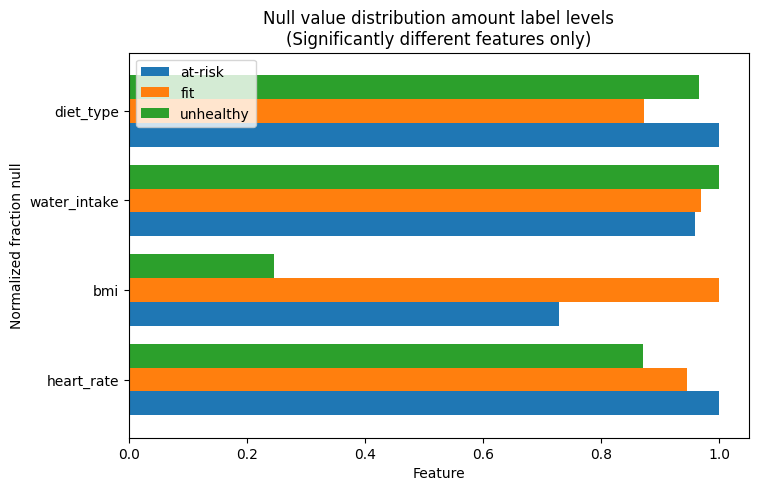

In [11]:
counts = df.drop('id', axis=1).groupby(df['health_condition']).count()
counts.drop('health_condition', axis=1, inplace=True)

normalized_fraction_null = (null_counts[sig_features] / (counts[sig_features] + null_counts[sig_features])) / null_counts[sig_features].sum()
normalized_fraction_null = normalized_fraction_null / normalized_fraction_null.max()

ax = normalized_fraction_null.T.plot(kind='barh', figsize=(8, 5), width=0.8)
plt.title('Null value distribution amount label levels\n(Significantly different features only)')
plt.xlabel('Feature')
plt.ylabel('Normalized fraction null')
plt.legend(loc='upper left')
plt.show()